### 1. Dependencies

In [106]:

import pandas as pd

import warnings
warnings.filterwarnings('ignore')


#functions
from functions.functions import low_high, set_first_row_to_zero
from functions.portfolio_strategy_design.univariate_sorting_preprocess import prepare_univariate_sorting_inputs
from functions.data_functions.get_data import get_row_universe, get_usa_universe,get_japan_universe, get_processed_fx_rates, get_snp_esg_merge_to_universe, get_refinitive_snp_merge_to_universe, get_famafrench_factors, get_processed_index, get_accounting_data
from functions.data_functions.process_data import process_row_universe, process_usa_universe, process_global_universe, process_japan_universe

In [107]:
#Important Filters
#############################################################

golden_data = "v_2C"

region_analysis = "North_America"

# Signal Characterization
action_characterization = "original_matteo"#"4_stakeholder_signals_Pre_Nikkei" # "original_matteo" # "Moji_5_signals", 4_signals_Pre_Nikkei, dict_all_SDG_1D


#esg only till 2022
esg_choice = "none" # "refinitiv_n_s&p" # "refinitiv_n_s&p"#"s&p"#"s&p"#"none"#""refinitiv_n_s&p" #refinitiv"

#Univariate Sorting Percentile Split number
no_simple_quantiles = 6

execute_3_filters = False

show_sector_portfolio =  False
show_sample_portfolio = False

start_year = 2018       # these ESG sources are aligned for `start_year==2013`
end_year = 2024


ff_factors_number = 3


#sector split
top_x_by_industry_even_split = 6

#Filtering the GOLDEN data equally top and bottom
use_alpha_bound = True




##############################


# Other Thresholds
# default: alpha_bound = 0.05
alpha_bound = 0.1    # percentage of extremes to exclude from the GOLDEN data
mktcap_covered = 0.95 # target market cap coverage per currency area # Filters bottom 5% of market cap

add_accounting_data = False

industry_level = 0 # 0 = map to larger groups, 1 = GICS_level_1, 2 = GICS_level_2

#Other Initalising variables
drop_real_estate = True
drop_fin = False
drop_utilities = False
drop_health_care = False

fama_factor_region = "Developed"
currency_filter = None
convert_to_USD = True
min_available_fyears = 3
drop_suspicious_gvkeys = True


if region_analysis == "Europe_and_North_America":
    #currencies we keep
    currency_filter = ['EUR', 'USD'] #['JPY'] #['CHF', 'GBP', 'EUR', 'USD'])]
    #region_filter = ["Europe", "United States and Canada"]
    convert_to_USD = True
    fama_factor_region = "Developed"
    execute_region_filters = False
    

if region_analysis == "Europe_and_North_America_and_Japan":
    #currencies we keep
    currency_filter = ['EUR', 'USD', 'JPY'] #['JPY'] #['CHF', 'GBP', 'EUR', 'USD'])]
    
    #check JPY currency conversion (Might need to invert it)
    
    #region_filter = ["Europe", "United States and Canada"]
    convert_to_USD = True
    fama_factor_region = "Developed"
    execute_region_filters = False
    


elif region_analysis == "North_America":
    currency_filter = ['USD'] 
    region_filter = ["United States and Canada"]
    execute_region_filters = True #If this is false there is rediculouly high alpha as it includes Irland and swiss
    fama_factor_region = "North_America"
    convert_to_USD = False
    

elif region_analysis == "Europe":
    currency_filter = ['EUR'] #"None" for uk
    region_filter = ["Europe"]
    execute_region_filters = True 
    #Keep in local currency
    #If we dont filter by EUR
    convert_to_USD = False    #True if UK
    fama_factor_region = "Europe"
  

elif region_analysis == "Japan":
    currency_filter = ['JPY'] 
    region_filter = ["Asia-Pacific"]
    execute_region_filters = True 
    #Keep in local currency
    convert_to_USD = False
    fama_factor_region = "Japan"

In [108]:
#Golden Dataset Location
from pathlib import Path
import os

golden_location = Path(
    os.environ.get(
        "GOLDEN_LOCATION",
        Path.home() / "Documents" / "GitHub" / "data" / "Golden_Data",
    )
)

# Golden Dataset
if golden_data == "v_2C":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2C_20260512.csv")
elif golden_data == "v_2B3":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2B3_20260511.csv")
elif golden_data == "v_2A":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2A.csv")
elif golden_data == "v_2B1":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2B1_20260409.csv")




# 1. Parameters 

In [109]:
# --- Parameter summary (prints below the cell) ---
from functions.output_paths import RUN_PARAM_NAMES, format_run_parameters

_run_parameters_text = format_run_parameters(globals(), RUN_PARAM_NAMES)
print(_run_parameters_text)


=== Run parameters ===
region_analysis              = 'North_America'
action_characterization      = 'original_matteo'
no_simple_quantiles          = 6
execute_3_filters            = False
golden_data                  = 'v_2C'
esg_choice                   = 'none'
start_year                   = 2018
end_year                     = 2024
fama_factor_region           = 'North_America'
ff_factors_number            = 3
currency_filter              = ['USD']
convert_to_USD               = False
drop_real_estate             = True
use_alpha_bound              = True
show_sector_portfolio        = False
industry_level               = 0
min_available_fyears         = 3
top_x_by_industry_even_split = 6
alpha_bound                  = 0.1
mktcap_covered               = 0.95



Signal Design

In [110]:
from functions.signal_design.signal_definitions import dict_all_SDG_1D, dict_2d_actions_stakeholders_original_matteo, dict_5_signals_Action_1D_Moji,dict_4_signals_Action_1D_Pre_Nikkei, dict_5_stakeholder_signals_Pre_Nikkei, dict_4_stakeholder_signals_Pre_Nikkei

#Choose which action characterization to use, which is dependent on function

#categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_all_SDG_1D()

if action_characterization == "original_matteo":
    categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_2d_actions_stakeholders_original_matteo()

    #What signals to include~~~
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
}
elif action_characterization == "Moji_5_signals":
    categories_dict, signal_0_name, signal_1_name, signal_2_name, signal_3_name, signal_4_name = dict_5_signals_Action_1D_Moji()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
        "signal_3": signal_3_name,
        "signal_4": signal_4_name,
    }

elif action_characterization == "4_signals_Pre_Nikkei":
    categories_dict, signal_0_name, signal_1_name, signal_2_name, signal_3_name = dict_4_signals_Action_1D_Pre_Nikkei()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
        "signal_3": signal_3_name,
    }

elif action_characterization == "5_stakeholder_signals_Pre_Nikkei":
    categories_dict, signal_0_name, signal_1_name, signal_2_name, signal_3_name, signal_4_name = dict_5_stakeholder_signals_Pre_Nikkei()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
        "signal_3": signal_3_name,
        "signal_4": signal_4_name,
    }

elif action_characterization == "4_stakeholder_signals_Pre_Nikkei":
    categories_dict, signal_0_name, signal_1_name, signal_2_name, signal_3_name = dict_4_stakeholder_signals_Pre_Nikkei()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
        "signal_3": signal_3_name,
    }


elif action_characterization == "dict_all_SDG_1D":
    categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_all_SDG_1D()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
    }






Signal Choice

In [111]:

analyse_high_low = "High"
if esg_choice == "none":

    universe_signals = {}

    if analyse_high_low == "High":
        analysis_selection = [("signal_2", "high"), ("signal_1","high"), ("signal_0","high")]
    elif analyse_high_low == "Low":
        analysis_selection = [("signal_2", "low"), ("signal_1","low"), ("signal_0","low")]



elif esg_choice == "refinitiv":
    universe_signals = {"esg_refinitive": "esg_refinitive",}
    analysis_selection = [("signal_2", "high"), ("esg_refinitive", "high")]
elif esg_choice == "s&p":
    universe_signals = {    "esg_sp": "esg_sp",}
    analysis_selection = [("esg_sp", "high"), ("esg_sp", "low"), ("signal_0", "high"), ("signal_1", "high"), ("signal_2", "high")]
elif esg_choice == "refinitiv_n_s&p":
    universe_signals = {    "esg_sp": "esg_sp",    "esg_refinitive": "esg_refinitive",}
    analysis_selection = [("signal_2", "high"), ("esg_refinitive", "high"), ("esg_sp", "high")]

### 2. Data

#### 2.1 LC dataset

clean below

In [112]:
from functions.data_functions.process_lc import process_lc, map_sectors, filter_sum_activities_by_fiscal_year_quantiles

lc = process_lc(lc, start_year, end_year)



# Additional Filters!



if execute_3_filters:
    #1-------------Filter companies with less than 3 years of data


    from functions.data_functions.process_lc import add_available_fyears
    lc = add_available_fyears(lc)

    print(f"Before filtering companies with less than {min_available_fyears} years of data: ", lc.shape)
    lc = lc[lc["n_available_fyears"] >= min_available_fyears]
    print(f"After filtering companies with less than {min_available_fyears} years of data: ", lc.shape)



    #2-------------Filter out suspicious gvkeys

    if drop_suspicious_gvkeys:
        print("Shape before: ", lc.shape)

        lc_suspicious = pd.read_csv(golden_location / "lc_gvkey_suspicious.csv")

        print("Number of suspicious: ", lc_suspicious.shape[0])
        print(lc_suspicious["suspicious_flag"].value_counts())

        lc_suspicious["original_gvkey"] = lc_suspicious["original_gvkey"].astype(str).str.zfill(6)
        lc["gvkey"] = lc["gvkey"].astype(str).str.zfill(6)
        print("Number of suspicious that are NAN: ", lc_suspicious["suspicious_flag"].isna().sum())

        print("unique gvkeys: ", lc["gvkey"].nunique(), "Unique gvkeys in suspicious: ", lc_suspicious["original_gvkey"].nunique())
        lc = lc.merge(lc_suspicious[["original_gvkey", "suspicious_flag", "likely_reason_codes"]], left_on="gvkey", right_on="original_gvkey", how="left")
        print(lc["suspicious_flag"].value_counts())
        print("Number of suspicious that are NAN: ", lc["suspicious_flag"].isna().sum())
        lc.to_csv("./data/debug/lc_before_suspicious_filtered.csv")
        lc = lc[lc["suspicious_flag"] != True]
        print("Shape after filtering Truly Sus: ", lc.shape)


    #3-------------Filter out Annual Reports with Less tha 5 Total initaitves
    print("Before filtering Annual Reports: ", lc.shape)
    lc = lc[~((lc["n_predicted_initiatives"] < 5) & (lc["report_type"] == "Annual Report"))]
    print("After filtering Annual Reports: ", lc.shape)



    lc.to_csv("./data/debug/lc_after_all_filter.csv")







if drop_real_estate:
    lc = lc[lc['GICS_level_1'] != 'Real Estate']




>>>> add_missing_gvkeys: filled 0 rows
Added SREC columns:  Index(['customers', 'employees', 'environment',
       'local communities and society', 'nothing', 'shareholders',
       'suppliers'],
      dtype='object')


In [113]:


if industry_level == 0:
    lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)
elif industry_level == 1:
    lc['Industry'] = lc['GICS_level_1']
elif industry_level == 2:
    lc['Industry'] = lc['GICS_level_2']


if drop_fin:
    lc = lc[lc['Industry'] != 'Financial']

if drop_utilities:
    lc = lc[lc['Industry'] != 'Utilities']

if drop_health_care:
    lc = lc[lc['Industry'] != 'Health Care']

# # Filter to keep a stable panel meaning we have initiatives for all years
# gvkey_stable_panel = lc.groupby(['gvkey'])['gvkey'].count() == (lc['rfyear'].max()-lc['rfyear'].min()+1)
# gvkey_stable_panel = gvkey_stable_panel[gvkey_stable_panel].index
# lc = lc[lc['gvkey'].isin(gvkey_stable_panel)]


if execute_region_filters == True:
    lc = lc[lc["MacroRegion"].isin(region_filter)]


In [114]:
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]

    else:
        lc[f'sum_with_{value}'] = lc[key].values


lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)

In [115]:
lc["sum_activities"].describe()

count    11012.000000
mean        26.540774
std         27.545424
min          0.000000
25%          8.000000
50%         19.000000
75%         36.000000
max        612.000000
Name: sum_activities, dtype: float64

In [116]:
if use_alpha_bound:

    lc = filter_sum_activities_by_fiscal_year_quantiles(
        lc,
        lower_exclude= (alpha_bound/2),
        upper_exclude= (alpha_bound/2),
    )

else:
    lower_exclude = 0.2*2
    upper_exclude = 0.05*2

    lc = filter_sum_activities_by_fiscal_year_quantiles(
        lc,
        lower_exclude= (lower_exclude/2),
        upper_exclude= (upper_exclude/2),
    )

In [117]:
lc["sum_activities"].describe()

count    9728.000000
mean       23.678146
std        17.476149
min         3.000000
25%         9.000000
50%        19.000000
75%        34.000000
max        80.000000
Name: sum_activities, dtype: float64

Create the signal

In [118]:
max_category = max(categories_dict.values())
for i in range(max_category+1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

Num stocks in USA and EU prior to some more filters

In [119]:
lc.loc[(lc['loc'] == 'USA') | (lc['MacroRegion'] == 'Europe'), 'gvkey'].nunique()

2526

#### 2.2 WRDS, Fama-French and FX data

Get and Process:
1- FX data

2- USA Universe

3- ROW Universe

4 - Japan

5 - ESG

4- Fama-French

5- Global Universe

6- Accounting Data

In [120]:
# Download from FRB H.10
# https://www.federalreserve.gov/datadownload/Output.aspx?rel=H10&series=d3efeda92e22923be9b7c3d7250706ac&lastobs=&from=01/01/2009&to=12/31/2024&filetype=csv&label=include&layout=seriescolumn
fx_rates = get_processed_fx_rates(end_year)

# Keep local-currency series for Europe/Japan analysis (no FX conversion)

usa_universe = get_usa_universe(start_year, end_year, download_wrds_data=False)
usa_universe = process_usa_universe(usa_universe)

row_universe = get_row_universe(start_year, end_year, download_wrds_data=False)
row_universe = process_row_universe(row_universe,fx_rates,convert_to_USD,)

japan_universe = get_japan_universe(start_year, end_year, download_wrds_data=False)
japan_universe = process_japan_universe(japan_universe,fx_rates,convert_to_USD,)

# This is a shortcut for the case without ESGs
if esg_choice == 'none':
    usa_universe['esg'] = 100
    row_universe['esg'] = 100
    japan_universe['esg'] = 100

elif esg_choice != 'none':
    if esg_choice == 'refinitiv_n_s&p':
        usa_universe, row_universe, japan_universe = get_snp_esg_merge_to_universe(usa_universe, row_universe, japan_universe)
        usa_universe, row_universe, japan_universe = get_refinitive_snp_merge_to_universe(usa_universe, row_universe, japan_universe)
    elif esg_choice == "refinitiv":
        usa_universe, row_universe, japan_universe = get_refinitive_snp_merge_to_universe(usa_universe, row_universe, japan_universe)
    elif esg_choice == "s&p":
        usa_universe, row_universe, japan_universe = get_snp_esg_merge_to_universe(usa_universe, row_universe, japan_universe)

fama_french = get_famafrench_factors(
    start_year,
    end_year,
    fama_factor_region,
    ff_factors_number,
    download_developed_ff_data=False,
)

global_universe = process_global_universe(usa_universe,row_universe,japan_universe,currency_filter,mktcap_covered,
    esg_choice,)

print("columns with year")
print([c for c in global_universe.columns if c == 'year' or c.startswith('year_')])

# if add_accounting_data:
#     #Note this will result in a lower sample and non-profitable stocks will be removed
#     global_universe = global_universe.drop(columns=['year_x'], errors='ignore')
#     global_universe = get_accounting_data(global_universe, region_analysis, start_year, end_year, dowload_acc_data = True)


#Ensure gvkey is 6 digits for merging
global_universe["gvkey"] = global_universe["gvkey"].astype(str).str.zfill(6)
lc["gvkey"] = lc["gvkey"].astype(str).str.zfill(6)

columns with year
['year']


In [121]:
# global_universe["gvkey"].astype(str).str.len().value_counts()   

In [122]:
# lc["gvkey"].astype(str).str.len().value_counts()   

In [123]:
lc["Industry"].unique()

array(['Consumer', 'Financial', 'ICT', 'Primary Industries',
       'Industrials', 'Health Care', 'Utilities'], dtype=object)

### 3. Univariate Portfolio sorting

In [124]:
cols_standardization = ['rfyear', 'curcdd', 'Industry']



prep = prepare_univariate_sorting_inputs(
    global_universe=global_universe,
    lc=lc,
    fama_french=fama_french,
    lc_signals=lc_signals,
    universe_signals=universe_signals,
    category_columns=sorted(categories_dict.keys()),
    cols_standardization=cols_standardization,
    apply_geo_filter=False,
)

global_universe = prep.global_universe
global_returns  = prep.global_returns
signals         = prep.signals        # dict: column name -> (date x gvkey_iid) pivot
signal_names    = prep.signal_names   # dict: column name -> display name
signal_df       = prep.global_long_df
fama_french     = prep.fama_french




# code to filter infinte stocks

In [125]:
# FIND ANY STOCKS THAT HAVE INF VALUES  

import numpy as np

bad_columns = set()
for df in signals.values():
    # numeric only, in case of odd dtypes
    num = df.select_dtypes(include=[np.number])
    if num.empty:
        continue
    bad_columns.update(num.columns[np.isinf(num).any(axis=0)].tolist())

bad_columns = list(bad_columns)

print("gvekys dropped due to inf values:")
print(bad_columns)


# filter these infinite values

signals = {
    name: df.drop(columns=bad_columns, errors="ignore")
    for name, df in signals.items()
}

import numpy as np
fit1 = signals['signal_0'].select_dtypes(include=["float", "float64"])
if np.isinf(fit1).sum().sum() > 0:
    print("There are inf values in the signal_0 column")

gvekys dropped due to inf values:
[]


% Nan in accounting data

In [126]:
# if add_accounting_data:
#     #Amount of missing accounting data as a percent
#     cols = ["roa0","roa1","roa2","ros0","ros1","ros2","sales_intensity"]
#     print((100 * global_universe[cols].isna().mean()).sort_values(ascending=False))

In [127]:
# MANUAL SETTINGS (for UnivariateQuantilePortfolio in the next section)
first_conditioning_set = 0       # momentum-like strategies: increase to skip early rows
no_simple_extremes_quantiles = 1 # high and low portfolios
take_extremes = False            # if True, low / middle / high extremes only


#### 3.1 Univariate sorting

In [128]:
from functions.portfolio_strategy_design.Univariate_Portfolio import UnivariateQuantilePortfolio

signal_quantiles: dict[str, pd.DataFrame] = {}
signal_quantile_constituents: dict[str, pd.Series] = {}

for col, pivot in signals.items():
    U = UnivariateQuantilePortfolio(
        signal=pivot,
        returns=global_returns,
        n_quantiles=no_simple_quantiles,
        first_conditioning_set=first_conditioning_set,
        take_extremes=take_extremes,
        n_extremes_quantiles=no_simple_extremes_quantiles,
    )
    signal_quantiles[col] = U.compute_returns()
    signal_quantile_constituents[col] = U.get_constituents_over_time()

# 4. Sector Split

In [129]:
# Store constituents over time + compute “next-month return” by Industry


from functions.portfolio_strategy_design.Sector_Portfolio import SectorPortfolio


if show_sector_portfolio:
    # Sector portfolio is pinned to signal_2.
    global_signal_2 = signals["signal_2"]

    #Build an industry pivot aligned to global_returns  and global_signal_*
    global_industry = global_universe.pivot(index="date", columns="gvkey_iid", values="Industry")

    #This will automatically split the even_split_no stocks into the unique sectors.
    #Select the n highest ranked stocks in each industruy and build portfolios using them.
    S = SectorPortfolio(
        signal=global_signal_2,
        returns=global_returns,
        global_universe=global_universe,
        sector_split=top_x_by_industry_even_split,          # fixed N per industry
        manual_input_split=False,
        first_conditioning_set=first_conditioning_set,
        ascending=False,
    )


    #all_industry_returns = S.compute_industry_returns()
    industry_constituents = S.get_constituents_over_time()   

    #Below assumes that ALLLL INDUSTIES HAVE THE SAME NUMBER OF STOCKS!!!!!!!!
    sector_portfolio_returns = S.equal_weight_mean_return() # equal-weight across industries


In [130]:
# Add Market Portfolios
market_factor = fama_french["mktrf"]

file_path = "./data/MSCI/MSCI_World.xlsx"
MSCI = get_processed_index(file_path, global_returns) 

In [131]:
# Transform in excess returns using the risk free rate

for col in signal_quantiles:
    signal_quantiles[col] = signal_quantiles[col].sub(fama_french['rf'].values, axis=0)

MSCI_excess_returns = MSCI["return"].sub(fama_french['rf'].values, axis=0)

if show_sector_portfolio:
    sector_portfolio_returns = sector_portfolio_returns.sub(fama_french["rf"].values, axis=0)


Excess_returns_sample = (
    global_returns.mean(axis=1)
    .sub(fama_french["rf"].values, axis=0)
    .to_frame("Sample")
)

#no need for market_factor


In [132]:
# Make sure the first row is 0, so they all start at the same date

global_returns = set_first_row_to_zero(global_returns)
for col in signal_quantiles:
    signal_quantiles[col] = set_first_row_to_zero(signal_quantiles[col])
    
# MSCI_excess_returns.iloc[0] = 0
market_factor.iloc[0] =0


if show_sector_portfolio:
    sector_portfolio_returns.iloc[0] = 0

# 5. Fama-French

In [133]:

if show_sector_portfolio:
    sector_portfolio_returns_df = pd.DataFrame()
    sector_portfolio_returns_df[f"Sector equal split {signal_2_name}"] = sector_portfolio_returns
    sector_portfolio_returns = sector_portfolio_returns_df

In [134]:
#### Rolling Alpha
from functions.portfolio_metrics.fama_french import rolling_ff_alphas

# Select what you want to analyse in the rolling alpha and cumulative returns
base_analysis_selection = [(s, "high") for s in reversed(lc_signals)]
base_analysis_selection.append(("signal_0", "low"))


if show_sector_portfolio:
    base_analysis_selection.append(("Sector equal split signal_2", "high"))




if esg_choice == "refinitiv":
    analysis_selection = [("esg_refinitive", "high"), ("signal_2", "high"), ("signal_1", "high")]
elif esg_choice == "s&p":
    analysis_selection = [("esg_sp", "high"), ("signal_2", "high"), ("signal_1", "high"), ("signal_0", "low")]
elif esg_choice == "none":
    analysis_selection = base_analysis_selection
    

rolling_alpha_selection = analysis_selection

_valid_buckets = {"high", "low"}
_invalid_buckets = sorted({b for _, b in rolling_alpha_selection} - _valid_buckets)
if _invalid_buckets:
    raise ValueError(f"Invalid bucket(s) in analysis_selection: {_invalid_buckets}. Use 'high' or 'low'.")

_missing_signal_keys = sorted({c for c, _ in rolling_alpha_selection} - set(signal_quantiles))
if _missing_signal_keys:
    raise KeyError(f"Signal key(s) in analysis_selection not found in signal_quantiles: {_missing_signal_keys}")

_bucket_to_col    = {"high": f"p_{no_simple_quantiles}", "low": "p_1"}
_bucket_to_prefix = {"high": "High", "low": "Low"}

rolling_signals_arg = [
    {
        "label": f"{_bucket_to_prefix[bucket]} {signal_names[col]}",
        "returns": signal_quantiles[col],
        "alpha_column": _bucket_to_col[bucket],
    }
    for col, bucket in rolling_alpha_selection
]


if show_sector_portfolio:
    _sector_label = f"Sector equal split {signal_2_name}"
    rolling_signals_arg.append({
        "label": _sector_label,
        "returns": sector_portfolio_returns,
        "alpha_column": _sector_label,
    })

if show_sample_portfolio:
    _market_sample_label = f"Sample"
    rolling_signals_arg.append({
        "label": _market_sample_label,
        "returns": Excess_returns_sample,
        "alpha_column": _market_sample_label,
    })

rolling_alphas_window_size_40 = rolling_ff_alphas(
    signals=rolling_signals_arg,
    fama_french=fama_french,
    window_size=40,
    n_factors=ff_factors_number,
)


rolling_alphas_window_size_24 = rolling_ff_alphas(
    signals=rolling_signals_arg,
    fama_french=fama_french,
    window_size=24,
    n_factors=ff_factors_number,
)




# 6. Performance Metrics

In [135]:
global_gross_portfolio_returns = pd.DataFrame(index=global_returns.index)
if show_sample_portfolio:
    global_gross_portfolio_returns['Sample'] = 1 + global_returns.mean(axis=1).sub(fama_french["rf"].values, axis=0)


global_gross_portfolio_returns["Market"] = 1 + market_factor 
# Single selection shared with rolling alpha.
portfolio_selection = analysis_selection

for col, bucket in portfolio_selection:
    quantile_col = _bucket_to_col[bucket]
    label        = f"{_bucket_to_prefix[bucket]} {signal_names[col]}"
    global_gross_portfolio_returns[label] = 1 + signal_quantiles[col][quantile_col]


if show_sector_portfolio:
    _sector_col = f"Sector equal split {signal_2_name}"
    global_gross_portfolio_returns[_sector_col] = 1 + sector_portfolio_returns[_sector_col]

#global_gross_portfolio_returns["MSCI benchmark"] = 1 + MSCI_excess_returns

# Add risk free rate back for cumulative returns
non_risk_free_returns = global_gross_portfolio_returns.add(fama_french["rf"].values, axis=0)
portfolio_returns = non_risk_free_returns - 1

# Cumulative Returns Plot

In [136]:
portfolio_returns.isna().sum()

Market                 0
High transformation    0
High preparation       0
High advocacy          0
Low advocacy           0
dtype: int64

In [137]:
from functions.portfolio_metrics.fama_french import ff3_regressions, ff5_regressions, rolling_ff_alphas

# FF3 table: every signal plus the sector portfolio.
ff3_parts = [
    low_high(
        ff3_regressions(signal_quantiles[col], fama_french.reset_index(drop=True)),
        signal_names[col],
    )
    for col in signal_quantiles
]
if show_sector_portfolio:
    ff3_parts.append(ff3_regressions(sector_portfolio_returns, fama_french.reset_index(drop=True)))

if show_sample_portfolio:
    ff3_parts.append(ff3_regressions(Excess_returns_sample, fama_french.reset_index(drop=True)))

ff3_parts_df = pd.concat(ff3_parts, axis=1).round(2)
#ff3_parts_df.to_csv('./output/ff3_' + _{start_date}-{end_date} + '.csv')
ff3_parts_df.head()

,Low advocacy,High advocacy,Low preparation,High preparation,Low transformation,High transformation
alpha,0.07,-0.07,0.03,-0.04,0.08,0.22
beta_mkt,1.00,1.06,1.00,1.05,1.04,0.98
beta_smb,0.13,0.27,0.21,0.18,0.21,0.18
beta_hml,0.30,0.35,0.30,0.31,0.30,0.24
p-value(alpha),0.61,0.65,0.87,0.78,0.57,0.16


In [138]:
# from functions.portfolio_metrics.fama_french import ff3_regressions, ff5_regressions, rolling_ff_alphas

# ff5_parts = [
#         low_high(
#             ff5_regressions(signal_quantiles[col], fama_french.reset_index(drop=True)),
#             signal_names[col],
#         )
#         for col in signal_quantiles
#     ]
# if show_sector_portfolio:
#         ff5_parts.append(ff5_regressions(sector_portfolio_returns, fama_french.reset_index(drop=True)))

# if show_sample_portfolio:
#         ff5_parts.append(ff5_regressions(Excess_returns_sample, fama_french.reset_index(drop=True)))

# ff5_parts_df = pd.concat(ff5_parts, axis=1).round(2)
#     #ff5_parts_df.to_csv('./output/ff5_' + _{start_date}-{end_date} + '.csv')

# ff5_parts_df.head(7)

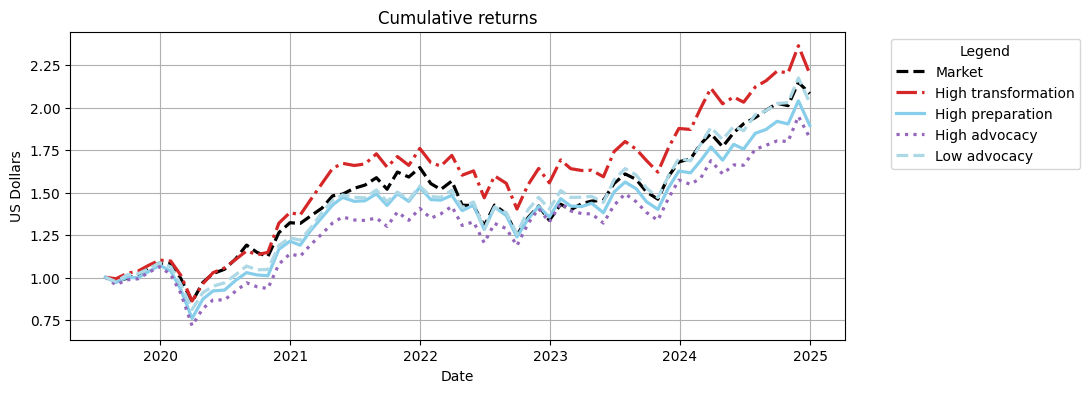

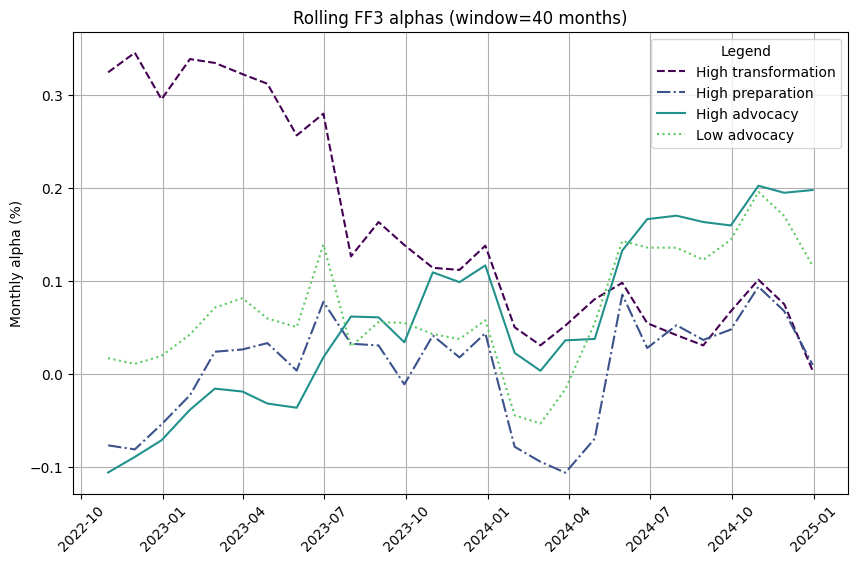

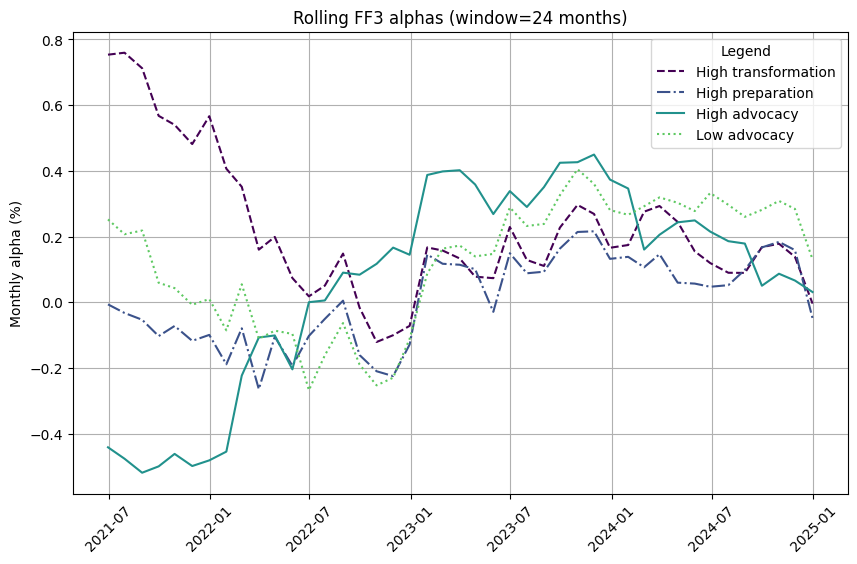

,1m,3m,YTD,1yr,3yr,5yr,10yr,Since launch
Market,-3.08%,2.82%,23.92%,23.92%,26.43%,91.86%,108.31%,108.31%
High transformation,-7.03%,-0.75%,17.09%,17.09%,24.90%,99.33%,119.85%,119.85%
High preparation,-7.12%,-1.26%,16.50%,16.50%,23.75%,76.82%,89.54%,89.54%
High advocacy,-6.48%,1.02%,15.83%,15.83%,29.58%,71.32%,82.29%,82.29%
Low advocacy,-6.77%,0.17%,19.19%,19.19%,31.81%,86.51%,102.78%,102.78%


,Sharpe,VaR 1%,Max Drawdown,Alpha,p-value(alpha)
Market,0.83,-10.81%,-24.13%,,
High transformation,0.84,-11.59%,-21.86%,0.22,0.160
High preparation,0.67,-13.19%,-29.19%,-0.04,0.780
High advocacy,0.62,-14.39%,-32.67%,-0.07,0.650
Low advocacy,0.76,-12.66%,-25.31%,0.07,0.610


In [139]:
from functions.portfolio_metrics.Strategy_Perfomance import StrategyPerformance
from functions.portfolio_metrics.fama_french import plot_rolling_alpha_function
from functions.output_paths import (
    output_csv_dir,
    output_images_dir,
    output_images_other_dir,
    output_run_dir,
    save_run_parameters,
)


start_date = str(portfolio_returns.index[0])[:7]
end_date = str(portfolio_returns.index[-1])[:7]

_run_dir = output_run_dir(
    action_characterization, region_analysis, start_date, end_date, no_simple_quantiles
)
_csv_dir = output_csv_dir(action_characterization, region_analysis, start_date, end_date, no_simple_quantiles)
_img_dir = output_images_dir(action_characterization, region_analysis, start_date, end_date, no_simple_quantiles)
_other_img_dir = output_images_other_dir(action_characterization, region_analysis, start_date, end_date, no_simple_quantiles)

save_run_parameters(_run_dir / "parameters.txt", globals())

ff_parts_df = ff3_parts_df if ff_factors_number == 3 else ff5_parts_df

sp = StrategyPerformance(portfolio_returns, ff3_parts_df=ff_parts_df)

_ff = fama_factor_region

_csv_dir.mkdir(parents=True, exist_ok=True)
ff_parts_df.to_csv(_csv_dir / f"ff{ff_factors_number}_regressions_ff-{_ff}.csv")

cumulative_table = sp.cumulative_performance_table(
    csv_path=_csv_dir / f"strategy_cumulative_performance_ff-{_ff}.csv")

risk_table = sp.performance_risk_metrics_table(
    csv_path=_csv_dir / f"strategy_performance_metrics_ff-{_ff}.csv")

sp.plot_cumulative_returns(
    title="Cumulative returns",
    tight_layout_rect = (0, 5, 100, 0.9),
    save_path=_img_dir / f"cumulative_returns_ff-{_ff}.png",
    csv_path=_csv_dir / f"gross_cumulative_returns_ff-{_ff}.csv",
)

# Note: sector-split alpha is appended later once `sector_portfolio_returns` exists.
plot_rolling_alpha_function(
    rolling_alphas_window_size_40,
    title=f"Rolling FF{ff_factors_number} alphas (window={40} months)",
    save_path=_img_dir / f"rolling_alphas_ff{ff_factors_number}_w{40}.png",
    csv_path=_csv_dir / f"rolling_alphas_ff{ff_factors_number}_w{40}.csv",
)

plot_rolling_alpha_function(
    rolling_alphas_window_size_24,
    title=f"Rolling FF{ff_factors_number} alphas (window={24} months)",
    save_path=_img_dir / f"rolling_alphas_ff{ff_factors_number}_w{24}.png",
    csv_path=_csv_dir / f"rolling_alphas_ff{ff_factors_number}_w{24}.csv",
)

display(cumulative_table)
display(risk_table)

# sp.plot_rolling_sharpe(window=40, save_path=_other_img_dir / f"strategy_rolling_sharpe_40m_ff-{_ff}.png")
#sp.plot_rolling_sharpe(window=60, save_path=_other_img_dir / f"strategy_rolling_sharpe_60m_ff-{_ff}.png")
# sp.plot_rolling_sharpe(window=24, save_path=_other_img_dir / f"strategy_rolling_sharpe_24m_ff-{_ff}.png")

# 7. Portfolio Constituents

### Portfolio constituents — category mix (`PortfolioConstituents`)

Uses `signal_2_simple_quantiles_constituents` and `global_universe` to inspect **Industry**, **`loc`**, and **MacroRegion**: line charts of stock counts over time (default = last quantile `p_k`, same as `constituents[i][-1]`) and donut charts for the **final** formation month. Optional: `analyse_all_portfolios_at_once=True` unions all `p_1`…`p_k`; `all_sub_portfolios=True` plots one subplot per quantile.


The following only inspects the high transformation

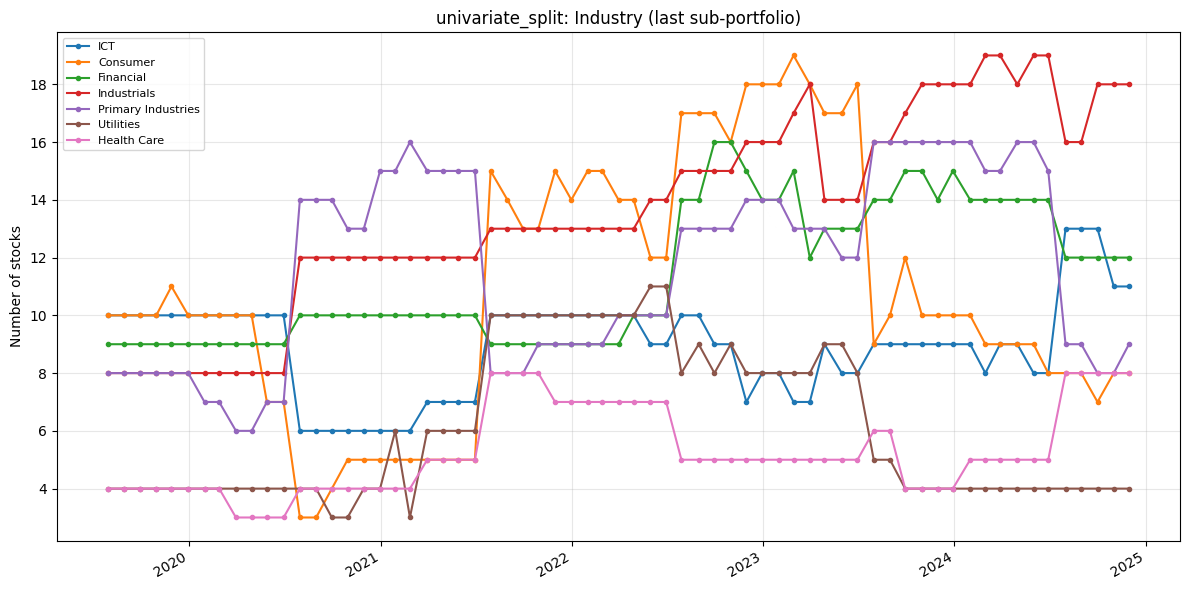

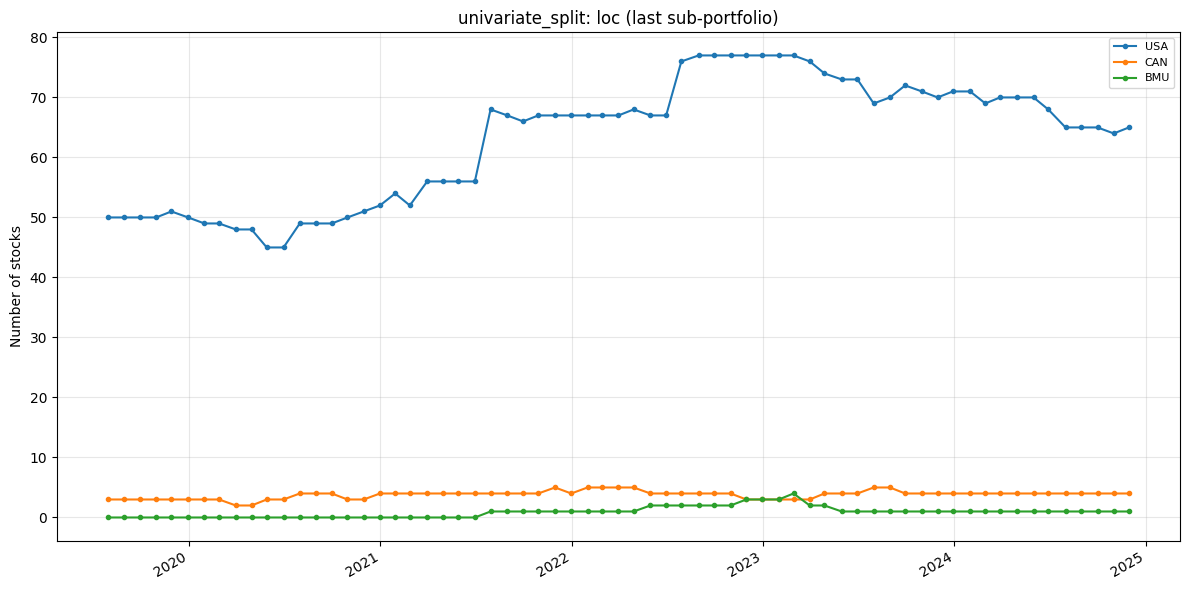

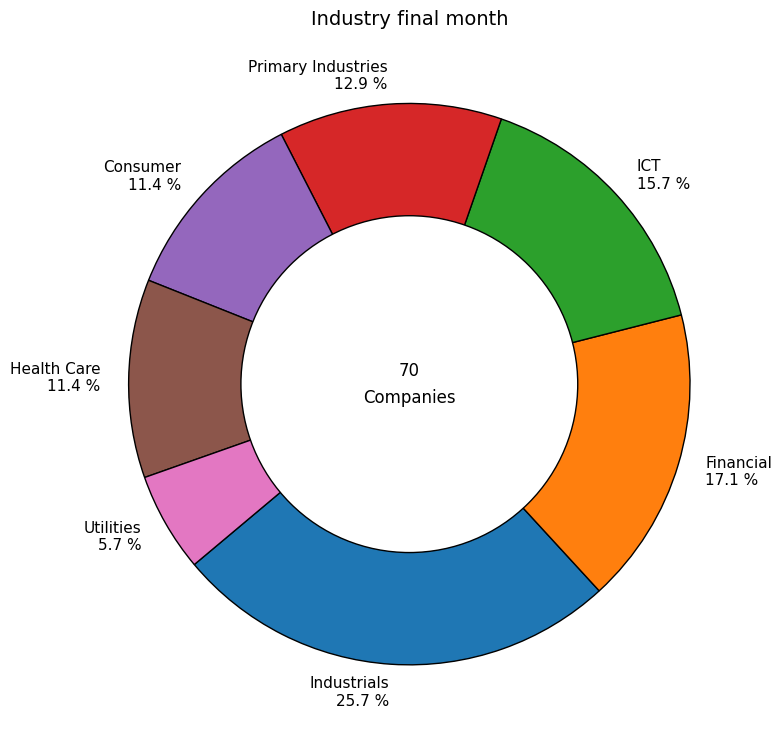

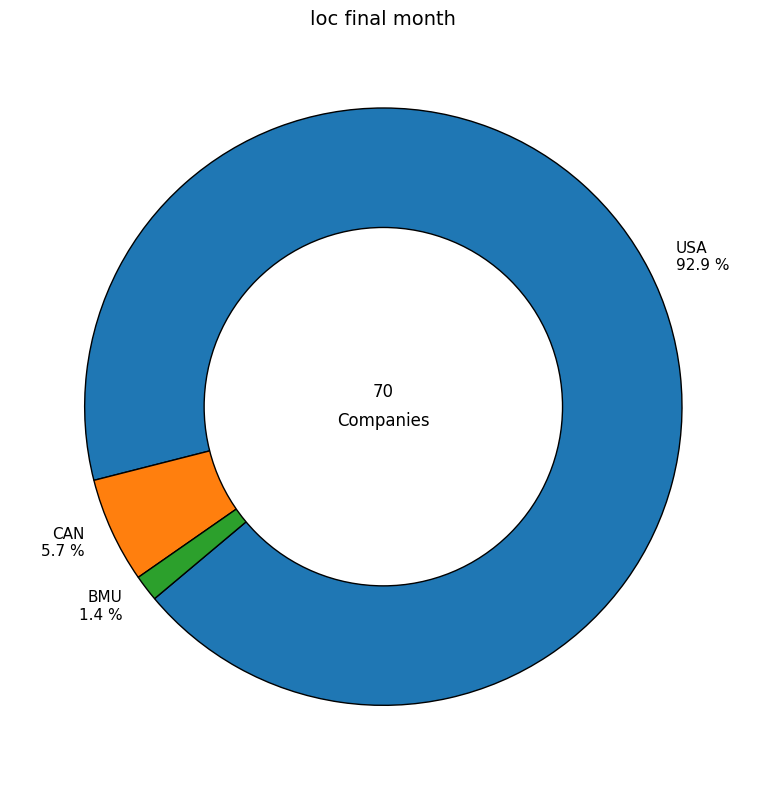

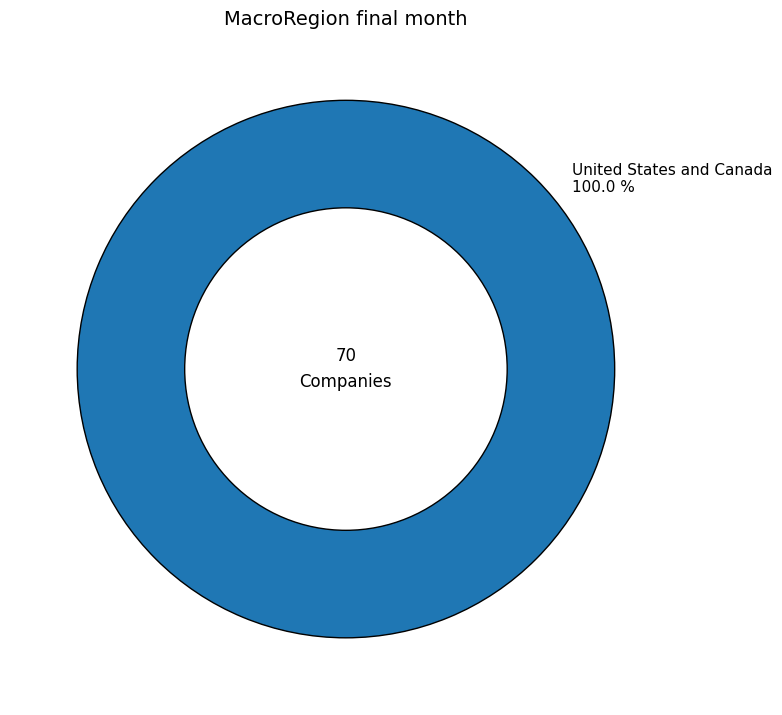

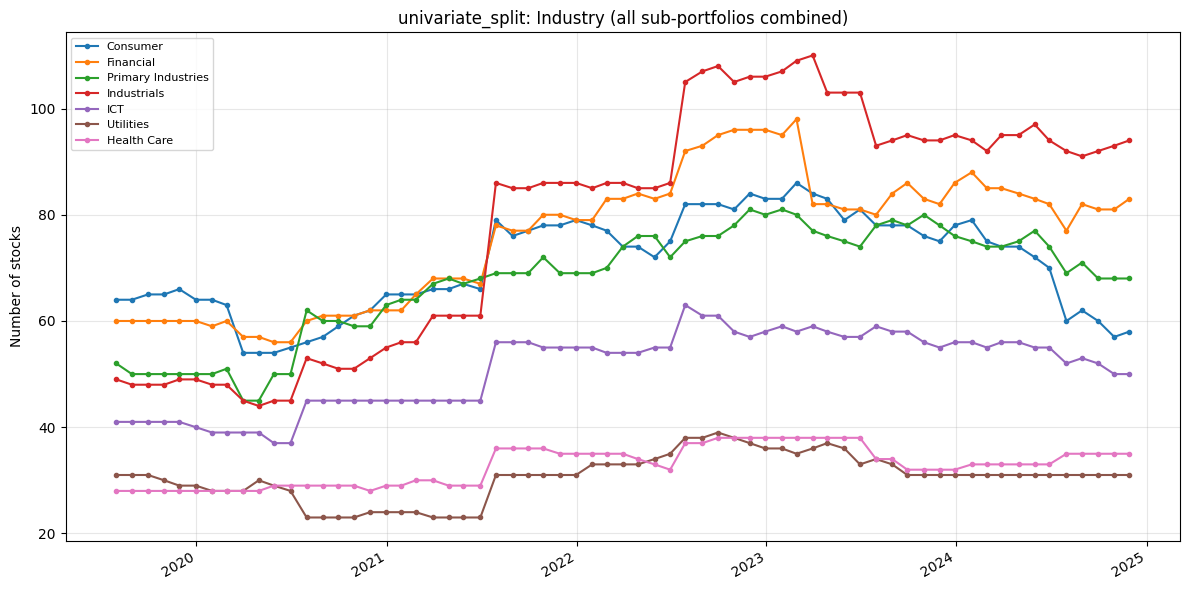

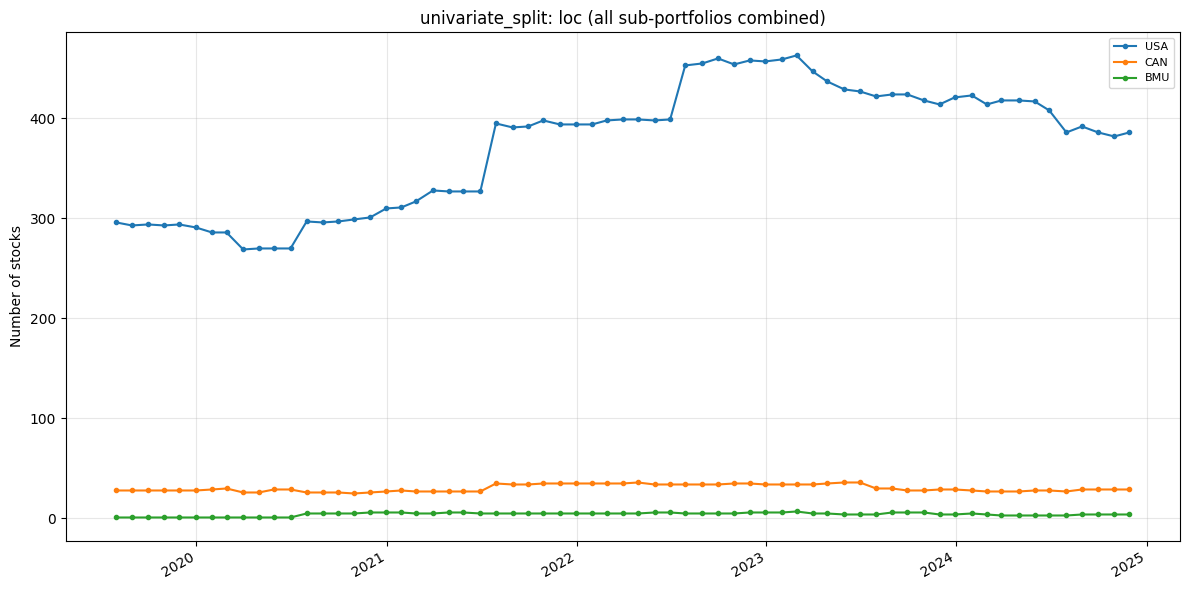

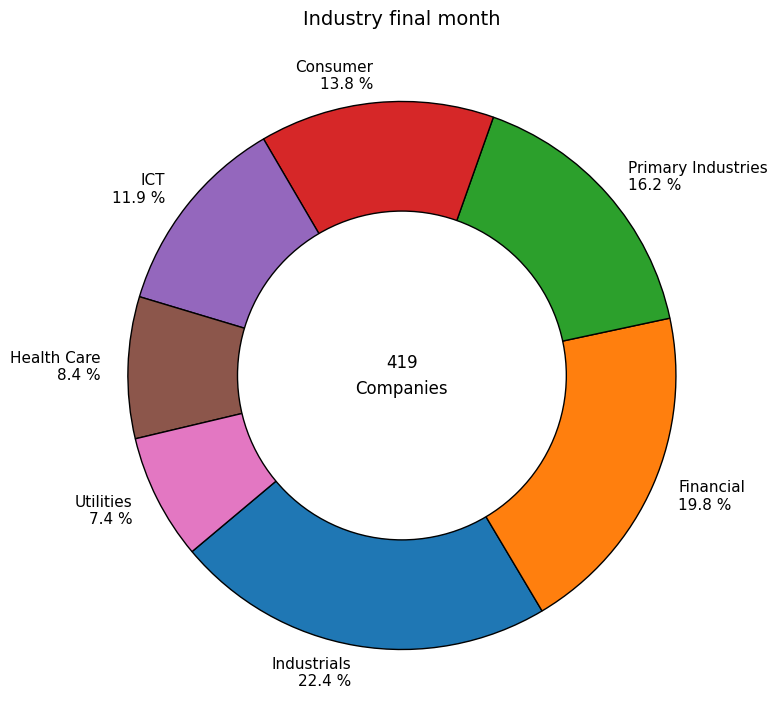

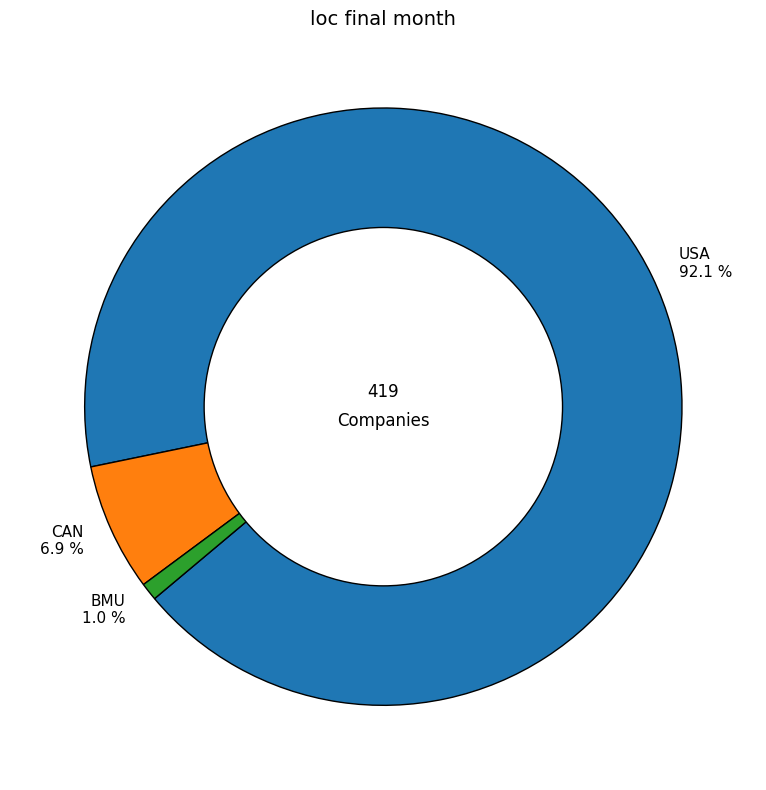

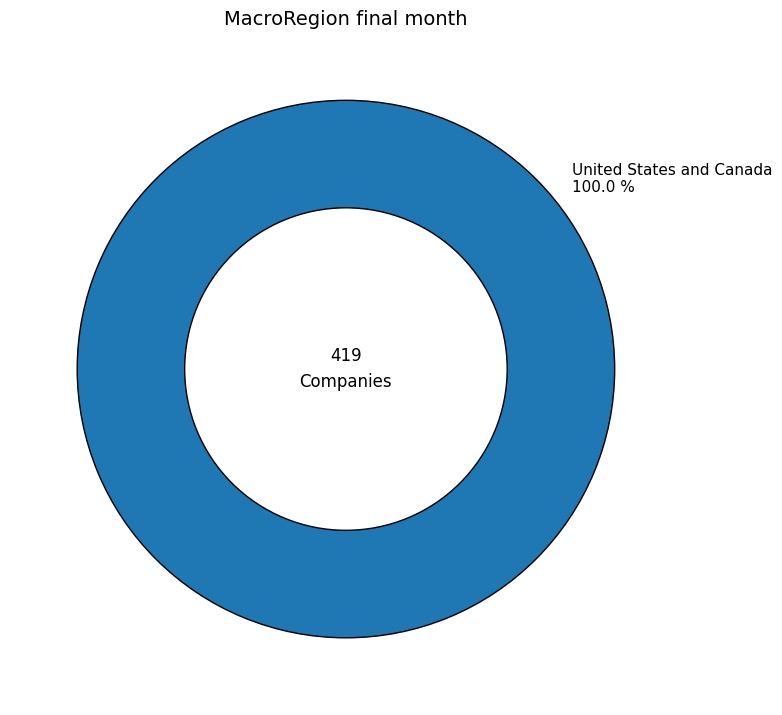

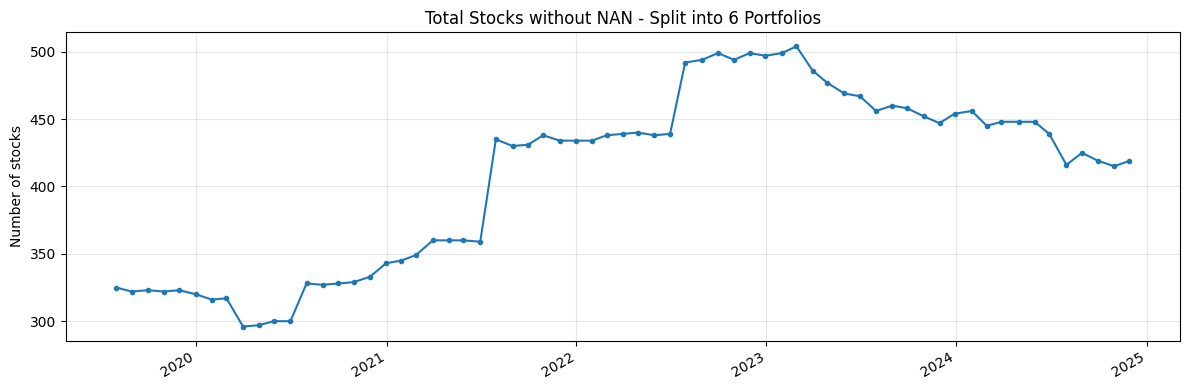

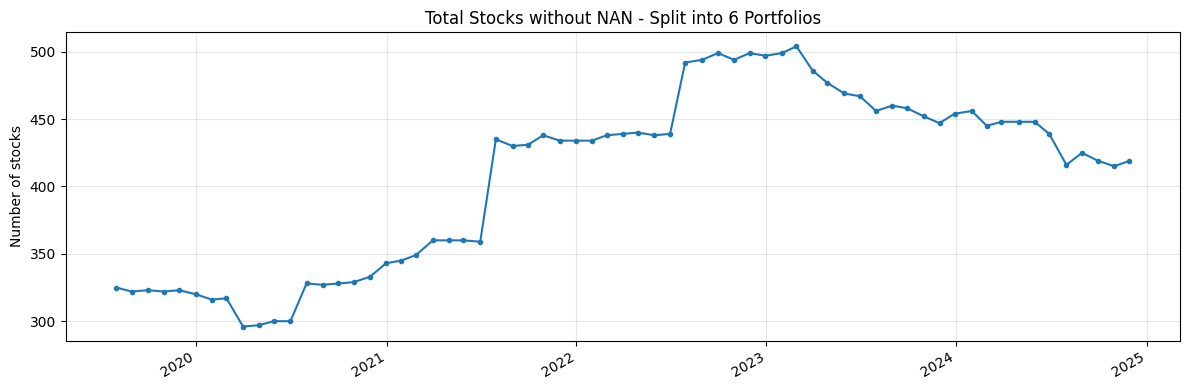

In [140]:
from IPython.display import display
from functions.portfolio_metrics.Portfolio_Constituents import PortfolioConstituents
from functions.output_paths import output_images_other_dir

# Portfolio constituents inspection is pinned to signal_2.
signal_2_simple_quantiles_constituents = signal_quantile_constituents["signal_2"]

if "start_date" not in globals() or "end_date" not in globals():
    _pc_dates = pd.to_datetime(signal_2_simple_quantiles_constituents.index)
    start_date = str(_pc_dates.min())[:7]
    end_date = str(_pc_dates.max())[:7]

_constituents_img_dir = output_images_other_dir(
    action_characterization, region_analysis, start_date, end_date, no_simple_quantiles
)

pc2 = PortfolioConstituents(
    signal_2_simple_quantiles_constituents,
    global_universe,
    portfolio_type="univariate_split",
)




_dates, wide_industry = pc2._counts_by_category_over_time(
    "Industry",
    portfolio_key=None,  # ignored when analyse_all_portfolios_at_once=True
    analyse_all_portfolios_at_once=False,
)

pc2.run_all_plots(save=True, show=True, out_dir=str(_constituents_img_dir))

# Options:
pc2.run_all_plots(
    analyse_all_portfolios_at_once=True, save=True, show=True, out_dir=str(_constituents_img_dir)
)
#pc2.run_all_plots(all_sub_portfolios=True, save=True, show=True)
# Plot (like your snippet)
pc2.total_stocks_over_time(title=f"Total Stocks without NAN - Split into {no_simple_quantiles} Portfolios")
